<a href="https://colab.research.google.com/github/angelamunozc/Talento-tech/blob/main/Proyecto_Esperanza_Vida_Prediccion_OK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Proyecto Esperanza de Vida Regresión

Angela Muñoz

Dataset disponible en https://www.kaggle.com/datasets/halimequintero/prediccion-esperanza-de-vida

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Ruta al archivo en Google Drive
ruta = '/content/drive/MyDrive/PROYECTO/data.csv' # Added a placeholder for the filename

# Importar la libreria pandas
import pandas as pd

# Cargar el dataset en un DataFrame
df = pd.read_csv(ruta)

# Set options to display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


# Display the first few rows of the DataFrame to confirm the changes
display(df.head())

# Display the total number of rows and columns
display(f"DataFrame shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


'DataFrame shape: (2938, 22)'

In [ ]:
# Drop the specified columns from the DataFrame
df = df.drop(['Country', 'Year', 'Status'], axis=1)

# Display the first few rows of the modified DataFrame
display(df.head())

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# Task
Provide a step-by-step Python code example using Keras to train a neural network for regression.

## Data preparation

### Subtask:
Scale the features to improve model performance.


**Reasoning**:
Scale the features in X_train and X_test using StandardScaler.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Instantiate a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform both training and test data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model definition

### Subtask:
Define the structure of the neural network using Keras.


**Reasoning**:
Define the neural network structure using Sequential and Dense layers as instructed.

Esta celda define la arquitectura de la red neuronal utilizando Keras.

from tensorflow.keras.models import Sequential: Importa la clase Sequential para crear un modelo de red neuronal secuencial (capa por capa).
from tensorflow.keras.layers import Dense: Importa la clase Dense para crear capas completamente conectadas.
model = Sequential(): Inicializa un modelo secuencial.
model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],))): Añade la primera capa densa. Tiene 64 neuronas (units=64), utiliza la función de activación ReLU (activation='relu') y especifica la forma de los datos de entrada (input_shape=(X_train.shape[1],)) que es el número de características en X_train.
model.add(Dense(units=32, activation='relu')): Añade una segunda capa densa con 32 neuronas y activación ReLU.
model.add(Dense(units=16, activation='relu')): Añade una tercera capa densa con 16 neuronas y activación ReLU.
model.add(Dense(units=1, activation=None)): Añade la capa de salida. Tiene 1 neurona (units=1) ya que es un problema de regresión (predecir un único valor) y no utiliza función de activación (activation=None) porque se predice un valor continuo.
model.summary(): Imprime un resumen de la arquitectura del modelo, mostrando el número de capas, la forma de salida de cada capa y el número de parámetros entrenables.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model
model = Sequential()

# Add the first Dense layer with input shape
model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)))

# Add additional Dense layers
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))

# Add the output Dense layer for regression
model.add(Dense(units=1, activation=None))

# Print the model summary to verify the structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

## Model compilation

### Subtask:
Compile the model by specifying the optimizer, loss function, and metrics.


**Reasoning**:
Compile the Keras model with the specified optimizer, loss function, and metrics for regression.
Esta celda compila el modelo de red neuronal definido anteriormente.

model.compile(optimizer='adam', loss='mse', metrics=['mae']): Configura el modelo para el entrenamiento.
optimizer='adam': Especifica el optimizador a utilizar, en este caso, el optimizador Adam, que es popular y eficaz.
loss='mse': Define la función de pérdida a minimizar durante el entrenamiento. Para problemas de regresión, el Error Cuadrático Medio (Mean Squared Error - MSE) es una opción común.
metrics=['mae']: Especifica la métrica a evaluar durante el entrenamiento y la evaluación. En este caso, el Error Absoluto Medio (Mean Absolute Error - MAE) se utiliza para entender la magnitud promedio de los errores de predicción.


In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

## Model training

### Subtask:
Train the neural network using the training data.


**Reasoning**:
Train the compiled Keras model using the specified training data, epochs, batch size, and validation data, and store the training history.
Esta celda entrena la red neuronal utilizando los datos de entrenamiento.

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test)): Inicia el proceso de entrenamiento.
X_train: Los datos de entrada para el entrenamiento.
y_train: La variable objetivo para el entrenamiento.
epochs=50: El número de veces que el modelo iterará sobre todo el conjunto de datos de entrenamiento.
batch_size=32: El número de muestras por actualización de gradiente.
validation_data=(X_test, y_test): Proporciona datos de validación para evaluar el rendimiento del modelo al final de cada época. Esto ayuda a detectar el sobreajuste.
history: Se almacena un objeto history que contiene información sobre la pérdida y las métricas para cada época durante el entrenamiento.



In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4779.2637 - mae: 68.3873 - val_loss: 3416.2080 - val_mae: 56.8457
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2396.1523 - mae: 44.8126 - val_loss: 263.9063 - val_mae: 13.2163
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 187.5788 - mae: 11.1291 - val_loss: 134.5524 - val_mae: 9.0882
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 126.5204 - mae: 8.9408 - val_loss: 105.9755 - val_mae: 7.9263
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 98.9326 - mae: 7.8735 - val_loss: 88.2689 - val_mae: 7.2004
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 82.6756 - mae: 7.2073 - val_loss: 75.9772 - val_mae: 6.6766
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 72.0299 - mae: 6.7878 - val_loss: 67.2253 - val_mae: 6.2976
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 67.6464 - mae: 6.3958 - val_loss: 58.7585 - val_mae: 5.8709
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s

## Model evaluation

### Subtask:
Evaluate the trained model on the test data.


**Reasoning**:
Evaluate the trained model on the test data to assess its performance on unseen examples.
Esta celda evalúa el rendimiento del modelo entrenado en el conjunto de datos de prueba.

loss, mae = model.evaluate(X_test, y_test, verbose=0): Evalúa el modelo en los datos de prueba. Devuelve el valor de la función de pérdida y las métricas especificadas durante la compilación (en este caso, MAE). verbose=0 suprime la salida detallada durante la evaluación.
print(f'Test Loss (MSE): {loss}'): Imprime el valor de la pérdida (MSE) en el conjunto de prueba.
print(f'Test MAE: {mae}'): Imprime el valor del Error Absoluto Medio (MAE) en el conjunto de prueba.



In [ ]:
# Evaluate the model on the test data
loss, mae = model.evaluate(X_test, y_test, verbose=0)

# Print the evaluation results
print(f'Test Loss (MSE): {loss}')
print(f'Test MAE: {mae}')

Test Loss (MSE): 8.32727336883545
Test MAE: 2.1121466159820557


## Prediction and analysis

### Subtask:
Make predictions on the test set and analyze the results.


**Reasoning**:
Make predictions on the test set, calculate the errors, calculate the Mean Absolute Error (MAE), and print the MAE.
Esta celda realiza predicciones utilizando el modelo entrenado y calcula el Error Absoluto Medio (MAE).

y_pred = model.predict(X_test): Realiza predicciones sobre el conjunto de datos de prueba X_test. y_pred contendrá los valores de esperanza de vida predichos por el modelo.
errors = y_pred.flatten() - y_test: Calcula la diferencia entre las predicciones (y_pred) y los valores reales (y_test). .flatten() se utiliza para asegurarse de que y_pred tenga la misma forma que y_test.
from sklearn.metrics import mean_absolute_error: Importa la función mean_absolute_error.
mae = mean_absolute_error(y_test, y_pred): Calcula el Error Absoluto Medio entre los valores reales (y_test) y las predicciones (y_pred).
print(f'Mean Absolute Error (MAE) on the test set: {mae}'): Imprime el MAE calculado en el conjunto de prueba.



In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the difference between predicted and actual values
errors = y_pred.flatten() - y_test

# Calculate the Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

# Print the calculated MAE
print(f'Mean Absolute Error (MAE) on the test set: {mae}')

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Mean Absolute Error (MAE) on the test set: 2.112146633174144


## Summary:

### Data Analysis Key Findings

*   The features in both the training and testing datasets were successfully scaled using `StandardScaler`.
*   A Keras `Sequential` model was defined with an input layer (64 units, 'relu'), two hidden layers (32 and 16 units, 'relu'), and an output layer (1 unit, no activation) for regression.
*   The model was compiled using the 'adam' optimizer, 'mse' as the loss function, and 'mae' as the metric.
*   The neural network was trained for 50 epochs with a batch size of 32, monitoring performance on the test set.
*   The evaluation of the trained model on the test data resulted in a Test Loss (MSE) of approximately 8.33 and a Test MAE of approximately 2.11.
*   Predictions were made on the test set, and the calculated Mean Absolute Error (MAE) on the test set was approximately 2.11.

### Insights or Next Steps

*   The MAE of approximately 2.11 on the test set indicates the average magnitude of the model's prediction errors. This value should be assessed in the context of the scale of the target variable to determine if it is acceptable.
*   Further steps could involve hyperparameter tuning (e.g., number of layers, units per layer, epochs, batch size, optimizer) to potentially improve the model's performance and reduce the MAE.


## Resumen:

### Hallazgos Clave del Análisis de Datos

* Las características en los conjuntos de datos de entrenamiento y prueba se escalaron con éxito utilizando `StandardScaler`.
* Se definió un modelo secuencial de Keras con una capa de entrada (64 unidades, 'relu'), dos capas ocultas (32 y 16 unidades, 'relu') y una capa de salida (1 unidad, sin activación) para regresión.
* El modelo se compiló utilizando el optimizador 'adam', 'mse' como función de pérdida y 'mae' como métrica.
* La red neuronal se entrenó durante 50 épocas con un tamaño de lote de 32, monitoreando el rendimiento en el conjunto de prueba.
* La evaluación del modelo entrenado en los datos de prueba resultó en una pérdida de prueba (MSE) de aproximadamente 8.33 y un MAE de prueba de aproximadamente 2.11.
* Se realizaron predicciones en el conjunto de prueba, y el error absoluto medio (MAE) calculado en el conjunto de prueba fue de aproximadamente 2.11.

### Conclusiones o Próximos Pasos

* El MAE de aproximadamente 2.11 en el conjunto de prueba indica la magnitud promedio de los errores de predicción del modelo. Este valor debe evaluarse en el contexto de la escala de la variable objetivo para determinar si es aceptable.
* Los siguientes pasos podrían incluir la optimización de hiperparámetros (por ejemplo, número de capas, unidades por capa, épocas, tamaño de lote, optimizador) para mejorar potencialmente el rendimiento del modelo y reducir el MAE.

Este código visualiza la distribución de los errores de predicción utilizando un histograma.

import matplotlib.pyplot as plt: Importa la biblioteca matplotlib.pyplot para crear gráficos.
import seaborn as sns: Importa la biblioteca seaborn para gráficos estadísticos más atractivos.
plt.figure(figsize=(10, 6)): Crea una nueva figura para el gráfico con un tamaño especificado.
sns.histplot(errors, kde=True): Crea un histograma de los errors (las diferencias entre predicciones y valores reales). kde=True añade una Estimación de Densidad del Kernel para mostrar la forma de la distribución.
plt.title('Distribution of Prediction Errors'): Establece el título del gráfico.
plt.xlabel('Prediction Error'): Establece la etiqueta del eje X.
plt.ylabel('Frequency'): Establece la etiqueta del eje Y.
plt.show(): Muestra el gráfico

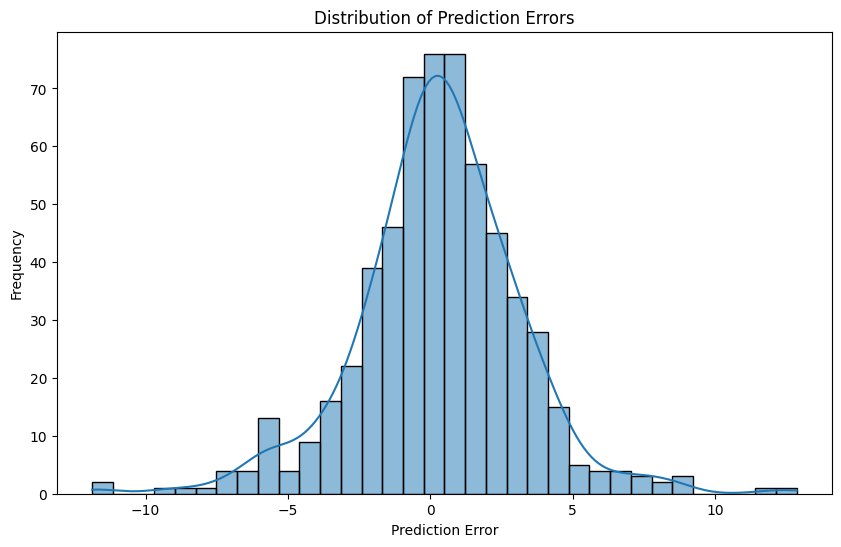

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a histogram of the errors
plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.show()

Este código visualiza la distribución de los errores de predicción utilizando un histograma.

import matplotlib.pyplot as plt: Importa la biblioteca matplotlib.pyplot para crear gráficos.
import seaborn as sns: Importa la biblioteca seaborn para gráficos estadísticos más atractivos.
plt.figure(figsize=(10, 6)): Crea una nueva figura para el gráfico con un tamaño especificado.
sns.histplot(errors, kde=True): Crea un histograma de los errors (las diferencias entre predicciones y valores reales). kde=True añade una Estimación de Densidad del Kernel para mostrar la forma de la distribución.
plt.title('Distribution of Prediction Errors'): Establece el título del gráfico.
plt.xlabel('Prediction Error'): Establece la etiqueta del eje X.
plt.ylabel('Frequency'): Establece la etiqueta del eje Y.
plt.show(): Muestra el gráfico

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

# Calculate the Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Print the calculated MAPE
print(f'Mean Absolute Percentage Error (MAPE) on the test set: {mape}')

Mean Absolute Percentage Error (MAPE) on the test set: 0.03194534507240773


La variable objetivo en el entrenamiento es y_train. Representa la variable que tu modelo está intentando predecir, que es 'Life expectancy' (Esperanza de vida) basándose en los pasos anteriores donde se eliminaron las columnas 'Country', 'Year' y 'Status'.

La predicción de la variable objetivo (Esperanza de vida) tiene un Error Absoluto Medio (MAE) de aproximadamente 2.11. Esto significa que, en promedio, las predicciones del modelo se desvían de los valores reales en aproximadamente 2 años aproximadamente.

El error porcentual absoluto medio es 0,03 %